# Sentinela Verde — demo do modelo de classificação de cobertura do solo

**Projeto:** monitoramento geoespacial de impacto ambiental/territorial no entorno de data centers, via séries temporais de imagens de satélite (Sentinel-2 / Landsat) — MBA Engenharia de Dados, Mackenzie.

Este notebook é um **preview rápido** do modelo oficial (`rf_v1.0-tuned`, Random Forest): mostra os hiperparâmetros e o dataset usados no treino, as métricas de avaliação em holdout, as matrizes de confusão, os mapas classificados (2013 vs. 2025) e a evolução da classe crítica — solo exposto/em obras — ao longo do tempo. Não é a entrega formal de notebooks reprodutíveis (SV-17, reservada para a fase final do cronograma); os números e figuras abaixo são **consumidos** de relatórios/artefatos já gerados, não recalculados aqui.

## Setup

Imports e localização do repositório (funciona independente de onde o notebook é executado a partir).

In [1]:
from pathlib import Path
import sys


def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("não encontrei a raiz do repositório (pyproject.toml) a partir do cwd do notebook")


REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

from sentinela.classes import CLASSES

FIGURES_DIR = REPO_ROOT / "reports" / "figures"
REPORTS_DIR = REPO_ROOT / "reports"
OUTPUTS_DIR = REPO_ROOT / "outputs" / "indicadores"
MODELS_DIR = REPO_ROOT / "models"

plt.rcParams["figure.dpi"] = 110
NOME_CLASSE = {cid: meta["nome_exibicao"] for cid, meta in CLASSES.items()}
COR_CLASSE = {cid: meta["cor_hex"] for cid, meta in CLASSES.items()}
print("Setup OK — classes carregadas de config/classes.yml:", list(NOME_CLASSE.values())[1:])

Setup OK — classes carregadas de config/classes.yml: ['Vegetação densa', 'Vegetação rala / pasto / agricultura leve', 'Solo exposto / em obras', 'Área construída / urbana', 'Água']


## 1. O modelo em números

O modelo oficial da V1 é `rf_v1.0-tuned` (Random Forest, scikit-learn), escolhido em `reports/experiments/EXP-003-tuning-hiperparametros.md` por bater ou melhorar o F1 da classe crítica (solo exposto/obras) nos dois recortes de holdout espacial **e** reduzir o tamanho em disco em 8,1% frente à versão anterior (`rf_v1.0`).

Carregamos o `.joblib` só para ler os metadados leves (hiperparâmetros do estimador, lista de features, seed, classes) — não rodamos `.predict` em nenhum momento deste notebook. O modelo pesa ~6,5 GB em disco; liberamos a memória logo depois de ler os metadados.

In [2]:
import gc
import joblib

modelo_path = MODELS_DIR / "rf_v1.0-tuned.joblib"
tamanho_gb = modelo_path.stat().st_size / 1e9

artefato = joblib.load(modelo_path)
estimador = artefato["modelo"]
hiperparametros = {
    "n_estimators": estimador.n_estimators,
    "max_depth": estimador.max_depth,
    "max_features": estimador.max_features,
    "min_samples_leaf": estimador.min_samples_leaf,
    "class_weight": estimador.class_weight,
    "random_state": estimador.random_state,
}
lista_features = artefato["lista_features"]
seed = artefato["seed"]
classes_modelo = list(artefato["classes_"])
versao_dataset = artefato["versao_dataset"]
sklearn_version = artefato["sklearn_version"]

del artefato, estimador
gc.collect()
print("metadados lidos, modelo liberado da memória")

metadados lidos, modelo liberado da memória


In [3]:
print(f"Versão oficial: rf_v1.0-tuned")
print(f"Dataset de treino usado: dataset_{versao_dataset}")
print(f"Tamanho do .joblib em disco: {tamanho_gb:.2f} GB")
print(f"scikit-learn: {sklearn_version}")
print(f"Seed (reprodutibilidade): {seed}")
print(f"Classes do estimador (ids): {classes_modelo}")
print(f"Nº de features: {len(lista_features)}")
print(f"Features: {lista_features}")

pd.DataFrame([hiperparametros])

Versão oficial: rf_v1.0-tuned
Dataset de treino usado: dataset_v1.0
Tamanho do .joblib em disco: 6.54 GB
scikit-learn: 1.9.0
Seed (reprodutibilidade): 42
Classes do estimador (ids): [1, 2, 3, 4, 5]
Nº de features: 14
Features: ['blue', 'green', 'red', 'nir', 'swir1', 'swir2', 'ndvi', 'evi', 'ndwi', 'mndwi', 'ndbi', 'bsi', 'ndmi', 'sensor_landsat']


,n_estimators,max_depth,max_features,min_samples_leaf,class_weight,random_state
0,300,30,sqrt,5,balanced_subsample,42


**Dataset de treino** (`dataset_v1.0`, ver `reports/experiments/EXP-003-tuning-hiperparametros.md`): **1.939.285 linhas** de treino (`split=="treino"` & `holdout_temporal==False`), agrupadas em **1.068 blocos espaciais** — o dataset completo (treino + avaliação) tem **3.798.750 linhas**, das quais **1.859.465** ficam reservadas para avaliação (holdout espacial e/ou temporal, nunca vistas no treino). O split nunca é aleatório por pixel — é por bloco espacial e/ou por ano, para evitar vazamento de dados entre treino e teste (decisão do time, ver `CLAUDE.md`).

## 2. Métricas de avaliação

Números reais de `reports/avaliacao_rf_v1.0-tuned.md` (gerado por `sentinela.evaluate`, que nunca chama `.fit` — só lê o modelo já treinado e avalia). Três recortes de holdout, do mais fácil ao mais difícil de generalizar:

- **(a) Holdout espacial** — `split=="teste"`: blocos espaciais nunca vistos no treino.
- **(b) Holdout temporal** — ano de 2025, nunca visto no treino.
- **(e) Holdout de AOI nunca vista** — sites inteiros (`ascenty-jundiai`, `ascenty-paulinia`, `hostdime-joao-pessoa`) reservados fora de qualquer split de treino. É a medida mais realista de "funciona num data center que o modelo nunca viu".

In [4]:
recortes = pd.DataFrame([
    {"recorte": "(a) Holdout espacial (split==teste)", "n": 1_693_912, "accuracy": 0.7882, "macro_f1": 0.7756, "f1_classe3": 0.5795},
    {"recorte": "(b) Holdout temporal (2025)", "n": 297_196, "accuracy": 0.7237, "macro_f1": 0.7256, "f1_classe3": 0.5940},
    {"recorte": "(e) Holdout de AOI nunca vista", "n": 777_016, "accuracy": 0.7845, "macro_f1": 0.7681, "f1_classe3": 0.5454},
])
recortes.set_index("recorte")

,n,accuracy,macro_f1,f1_classe3
recorte,,,,
(a) Holdout espacial (split==teste),1693912,0.7882,0.7756,0.5795
(b) Holdout temporal (2025),297196,0.7237,0.7256,0.5940
(e) Holdout de AOI nunca vista,777016,0.7845,0.7681,0.5454


**Meta de referência** (termômetro, não critério de aprovação): macro-F1 ≥ 0.70 e F1(classe 3) ≥ 0.55 no holdout espacial (a). O modelo bate os dois: macro-F1 = 0.7756, F1(classe 3) = 0.5795. No holdout de AOI nunca vista (e) — o teste mais difícil — o macro-F1 segue acima da meta (0.7681) mas o F1 da classe 3 fica um pouco abaixo (0.5454).

### Detalhe por classe — holdout espacial (a)

A classe 3 (solo exposto/obras, crítica para o projeto) é a mais difícil das cinco em qualquer recorte — destacada na tabela abaixo.

In [5]:
detalhe_espacial = pd.DataFrame([
    {"classe": NOME_CLASSE[1], "precision": 0.873, "recall": 0.885, "f1": 0.879, "suporte": 422434},
    {"classe": NOME_CLASSE[2], "precision": 0.724, "recall": 0.748, "f1": 0.736, "suporte": 413665},
    {"classe": NOME_CLASSE[3], "precision": 0.587, "recall": 0.572, "f1": 0.579, "suporte": 185319},
    {"classe": NOME_CLASSE[4], "precision": 0.792, "recall": 0.738, "f1": 0.764, "suporte": 436810},
    {"classe": NOME_CLASSE[5], "precision": 0.894, "recall": 0.948, "f1": 0.920, "suporte": 235684},
    {"classe": "macro avg", "precision": 0.774, "recall": 0.778, "f1": 0.776, "suporte": 1693912},
    {"classe": "weighted avg", "precision": 0.787, "recall": 0.788, "f1": 0.787, "suporte": 1693912},
]).set_index("classe")


def _destaca_classe3(row):
    cor = "background-color: #fdecea; font-weight: bold" if row.name == NOME_CLASSE[3] else ""
    return [cor] * len(row)


detalhe_espacial.style.apply(_destaca_classe3, axis=1).format(
    {"precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}", "suporte": "{:,}"}
)

,precision,recall,f1,suporte
classe,,,,
Vegetação densa,0.873,0.885,0.879,"422,434"
Vegetação rala / pasto / agricultura leve,0.724,0.748,0.736,"413,665"
Solo exposto / em obras,0.587,0.572,0.579,"185,319"
Área construída / urbana,0.792,0.738,0.764,"436,810"
Água,0.894,0.948,0.920,"235,684"
macro avg,0.774,0.778,0.776,"1,693,912"
weighted avg,0.787,0.788,0.787,"1,693,912"


**Por site, o desempenho da classe 3 não é uniforme**: no holdout espacial (a), o F1 varia de **0.216** (`scala-sgigsm01`) a **0.818** (`angonap-fortaleza`) — amplitude de 0.602. Sites com poucos exemplos de treino da classe 3 ficam bem abaixo da média (detalhe completo por site em `reports/avaliacao_rf_v1.0-tuned.md`, seção (c)).

## 3. Matrizes de confusão

Imagens já geradas por `sentinela.evaluate` — só exibidas aqui, não regeradas. Primeiro o holdout espacial (a) — absoluta e normalizada por linha — depois a comparação entre eras de sensor (Landsat 2013-2018 vs. Sentinel-2 2019-2025), que é onde a diferença de resolução (30 m vs. 10 m) mais aparece.

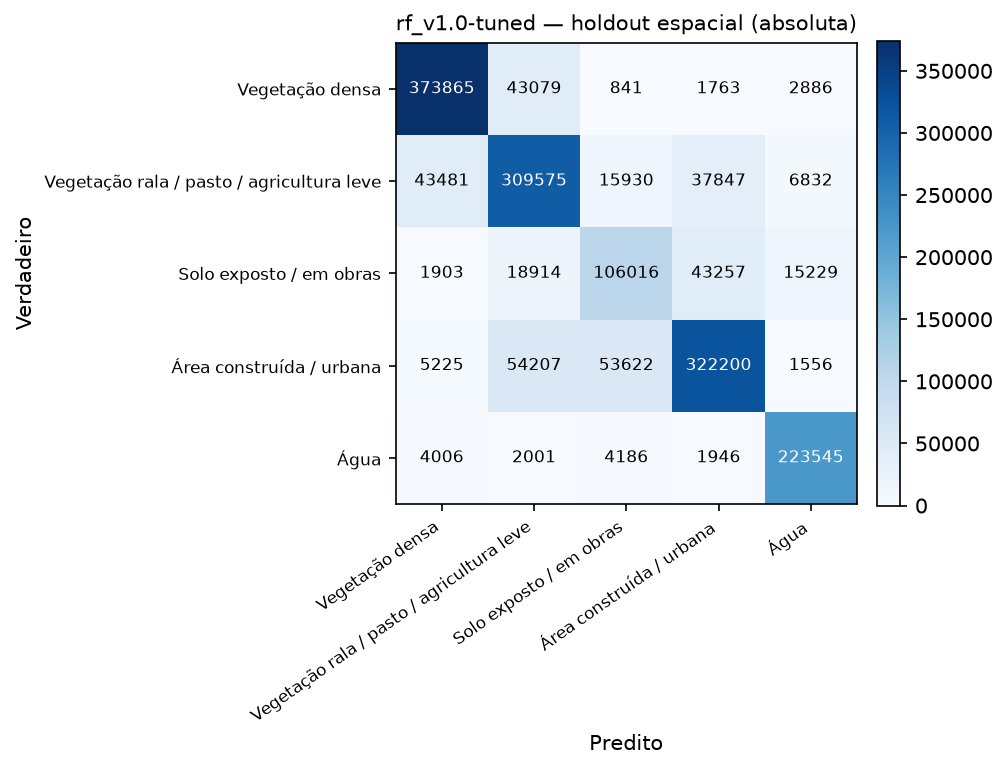

In [6]:
display(Image(filename=str(FIGURES_DIR / "matriz_confusao_espacial_rf_v1.0-tuned.png")))

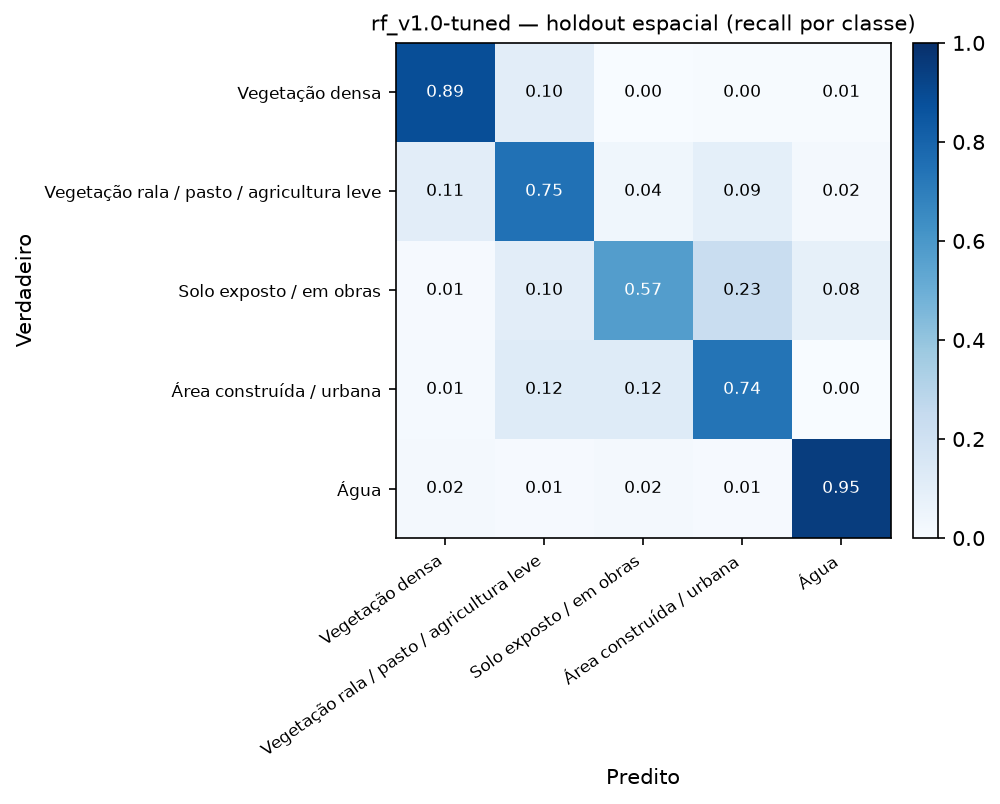

In [7]:
display(Image(filename=str(FIGURES_DIR / "matriz_confusao_espacial_normalizada_rf_v1.0-tuned.png")))

### Landsat vs. Sentinel-2

F1 da classe 3 cai de **0.5868** (Sentinel-2) para **0.4794** (Landsat) — recall de apenas 0.421 na era Landsat. A explicação mais provável é resolução (área mínima mapeável 9x maior em pixels Landsat de 30 m), não um defeito do modelo em si.

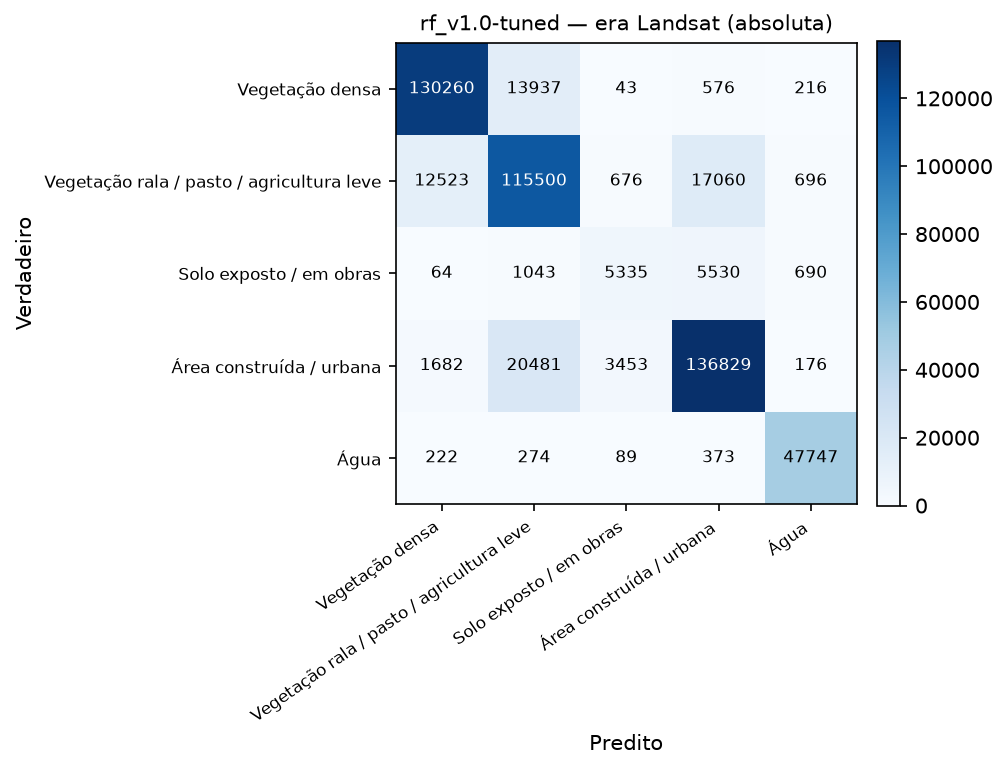

In [8]:
display(Image(filename=str(FIGURES_DIR / "matriz_confusao_era_landsat_rf_v1.0-tuned.png")))

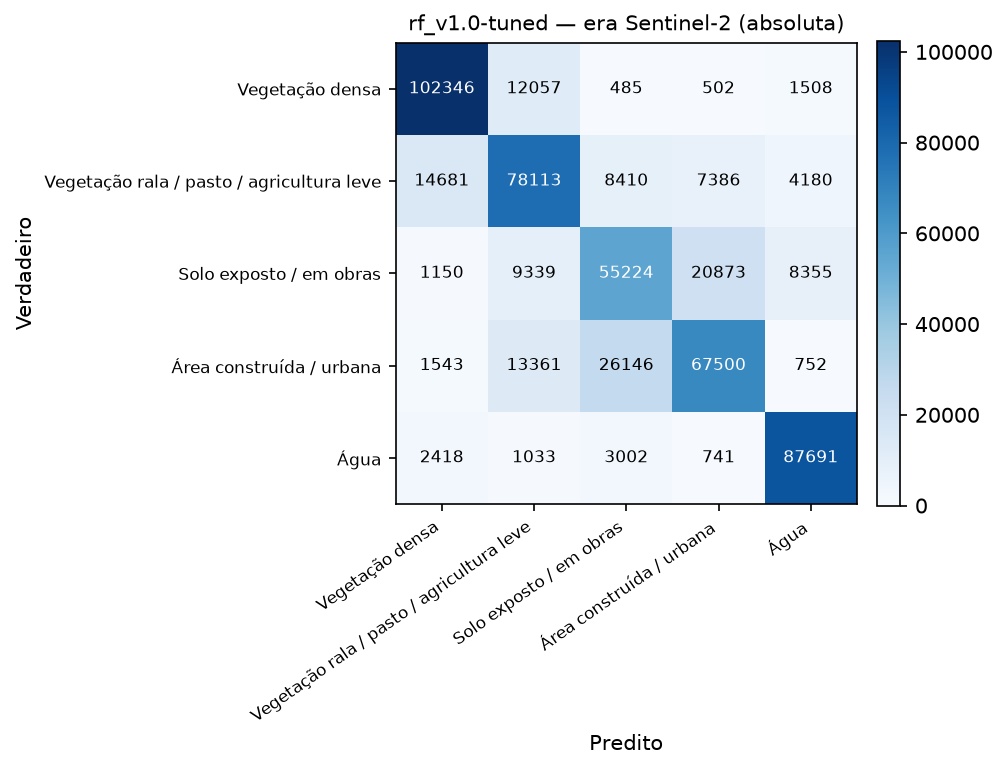

In [9]:
display(Image(filename=str(FIGURES_DIR / "matriz_confusao_era_s2_rf_v1.0-tuned.png")))

### Erros da classe crítica — inspeção visual

Contact sheet com 20 pixels errados envolvendo a classe 3 (solo exposto/obras), metade falso-negativo e metade falso-positivo, com o patch RGB verdadeiro por trás de cada erro. O padrão mais recorrente é confusão estrutural solo-telhado (nos dois sentidos) e via/estrada rotulada como "construída" pelo MapBiomas mas espectralmente mais próxima de solo exposto — detalhe completo em `reports/avaliacao_rf_v1.0-tuned.md`.

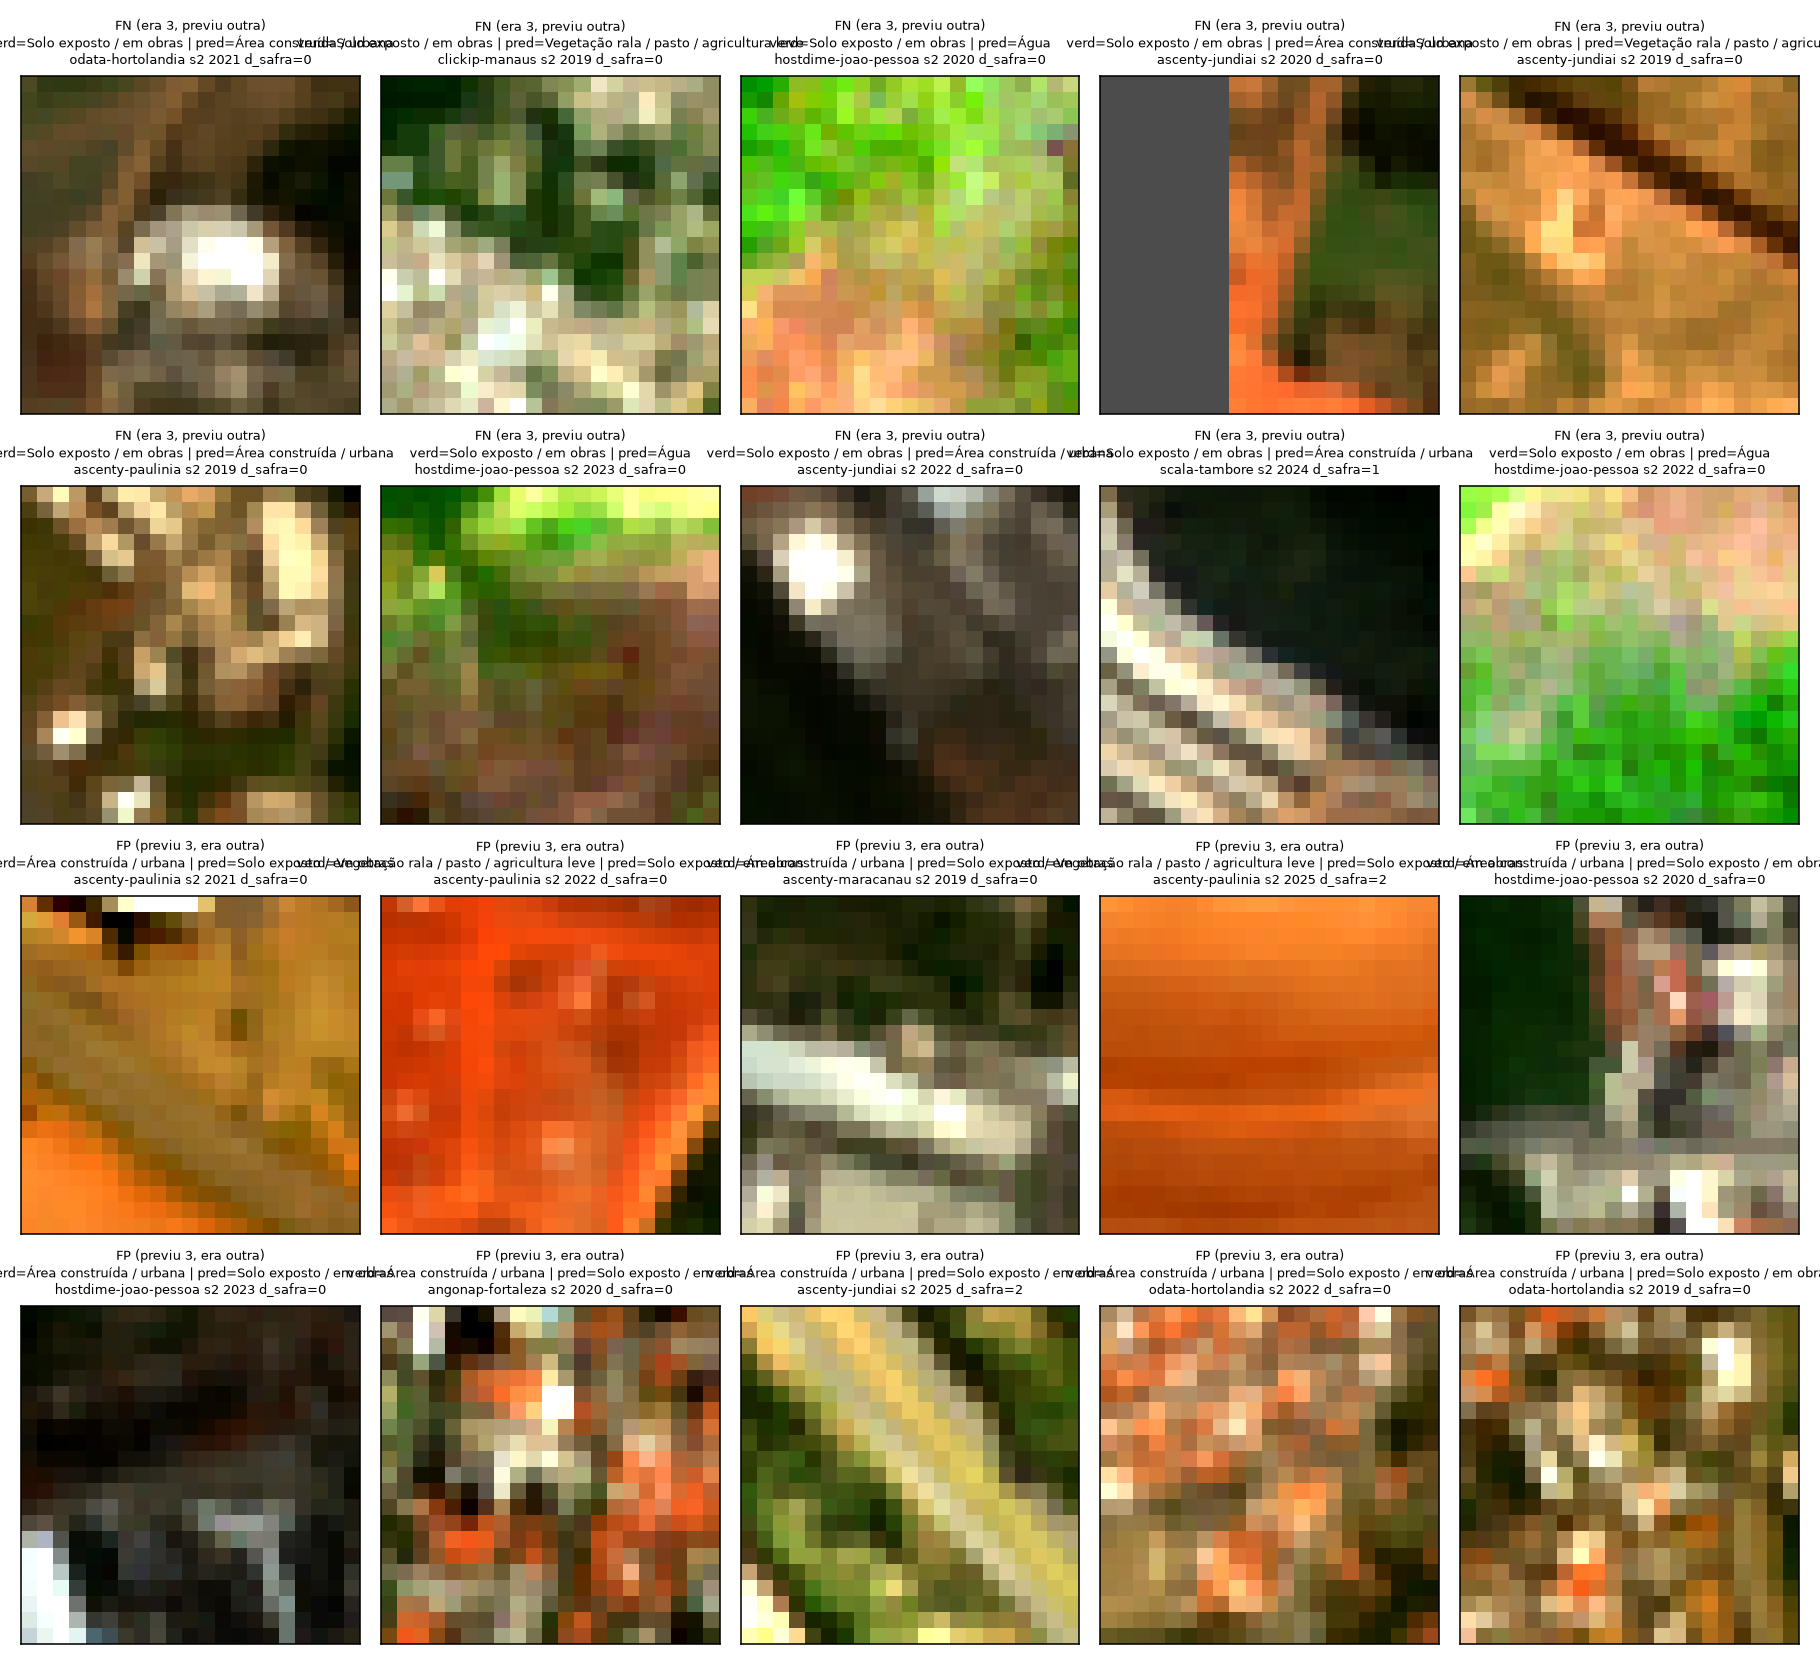

In [10]:
display(Image(filename=str(FIGURES_DIR / "classe3_erros_rf_v1.0-tuned.png")))

## 4. Mapas classificados — a peça central

Comparação lado a lado 2013 (Landsat) vs. 2025 (Sentinel-2) para dois sites, já classificados pelo modelo com as 5 classes coloridas e legenda. É a evidência visual direta do que as métricas acima resumem em números.

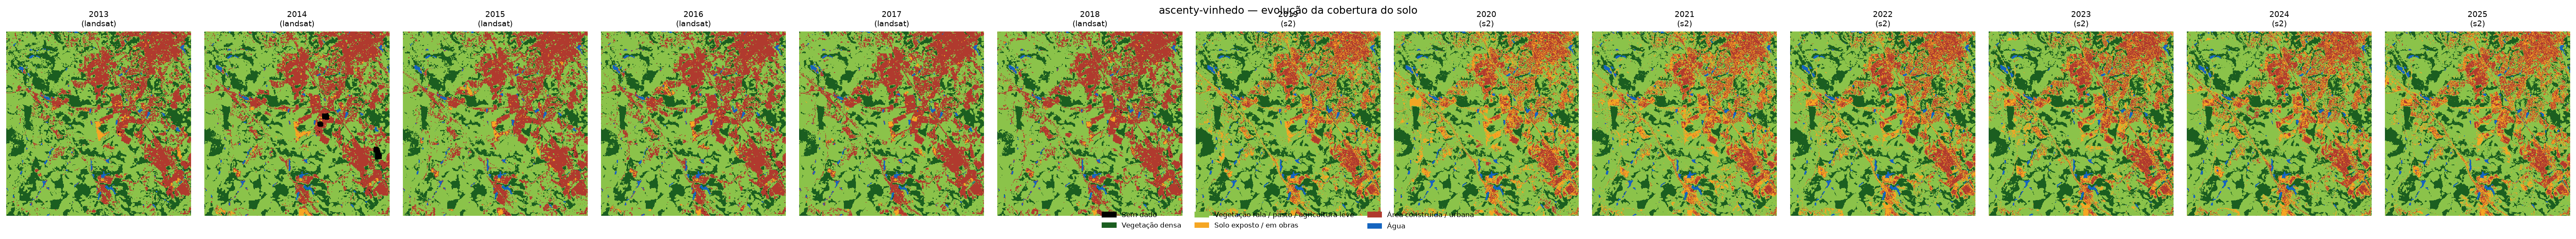

In [11]:
display(Image(filename=str(FIGURES_DIR / "mapa_comparacao_2013_2025_ascenty-vinhedo.png")))

**`ascenty-vinhedo`**: em 2013 o entorno é dominado por vegetação rala/pasto e vegetação densa; em 2025 aparecem manchas grandes de área construída/urbana onde antes havia vegetação ou solo exposto — a transição vegetação/pasto → solo exposto → construído que o projeto monitora.

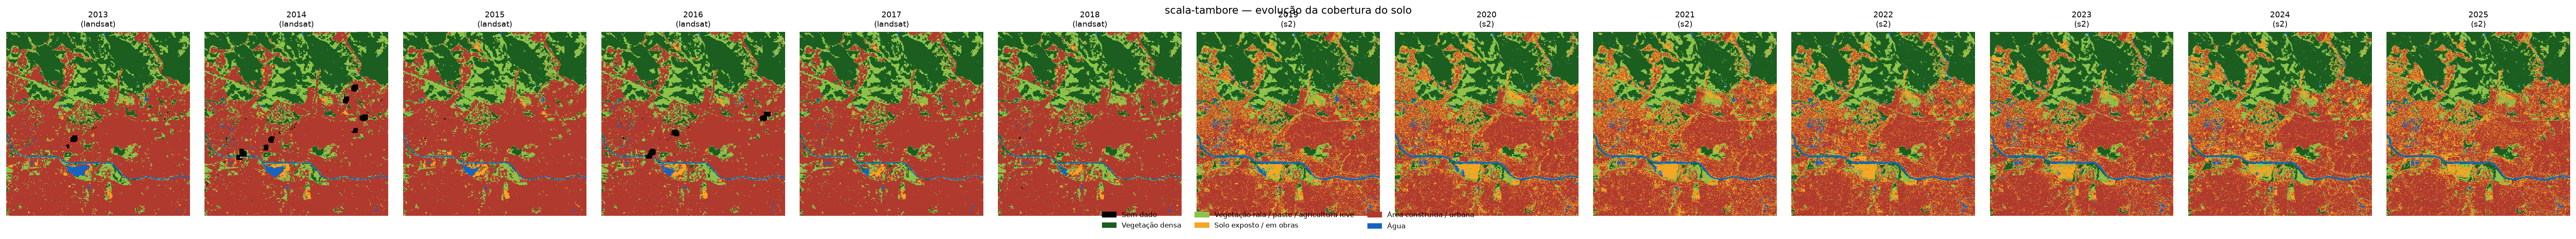

In [12]:
display(Image(filename=str(FIGURES_DIR / "mapa_comparacao_2013_2025_scala-tambore.png")))

**`scala-tambore`**: mesmo padrão de transição, com a área construída/urbana ganhando espaço de 2013 para 2025 — a classe 3 (solo exposto/obras) funciona como o sinal intermediário desse processo.

### Um terceiro site, individualmente

`odata-hortolandia`: mapa Landsat de 2013 e mapa Sentinel-2 de 2025, separados.

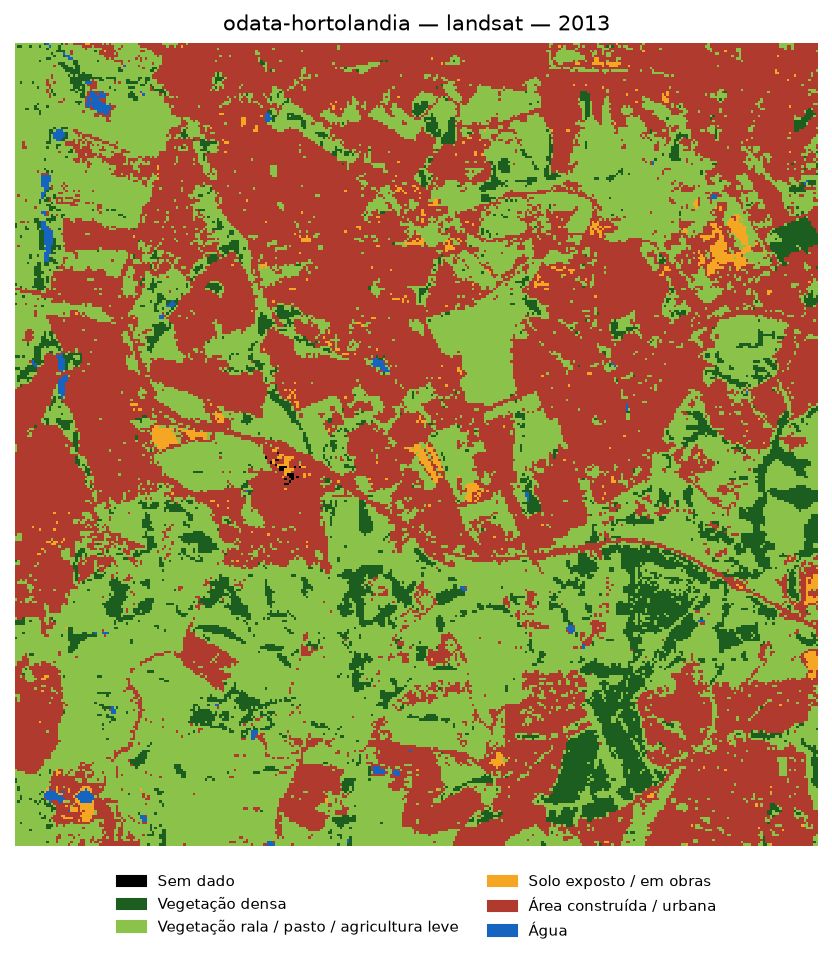

In [13]:
display(Image(filename=str(FIGURES_DIR / "mapa_landsat_odata-hortolandia_2013.png")))

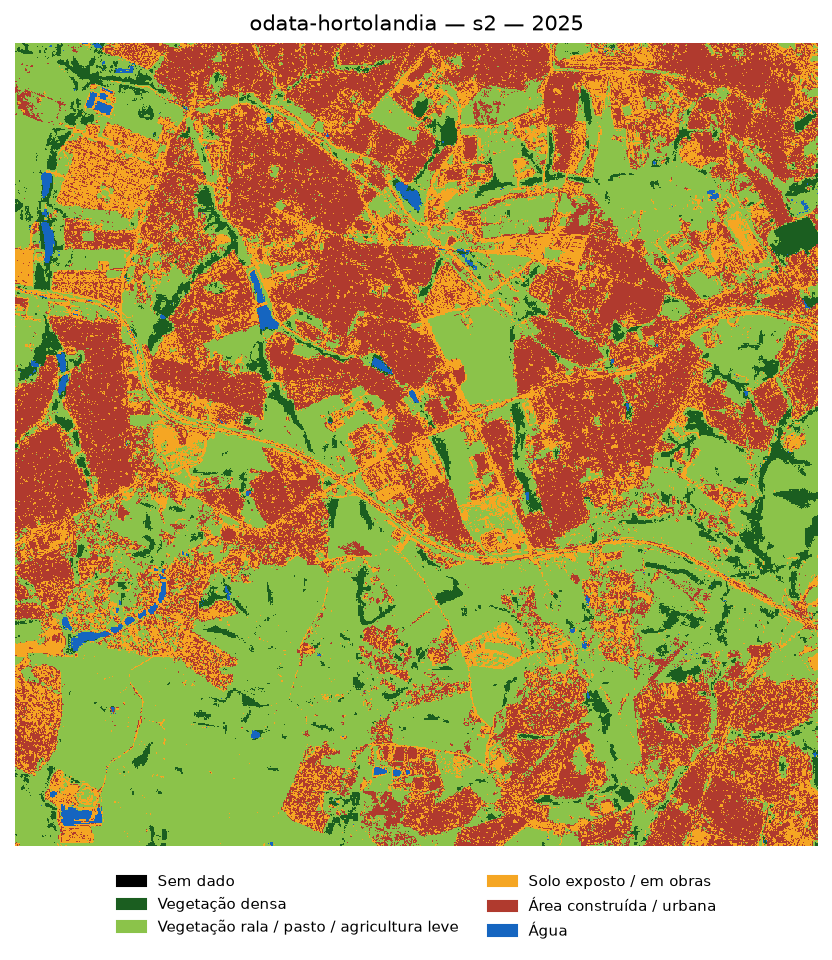

In [14]:
display(Image(filename=str(FIGURES_DIR / "mapa_s2_odata-hortolandia_2025.png")))

### Imagem crua vs. classificada — o que o satélite viu vs. o que o modelo decidiu

As seções acima mostram só o mapa já classificado. Aqui, lado a lado, para dois pares site/sensor/ano: a composição RGB **crua** (sem nenhuma classificação — só o dado que o satélite captou) e, ao lado, a mesma cena com a saída do modelo sobreposta pixel a pixel, nas 5 classes coloridas com legenda. As duas imagens de cada par vêm de arquivos já gerados (`composto_*` de `sentinela.gee.landsat._salvar_png_rgb` e `mapa_*` de `sentinela.predict.gerar_png_conferencia`, ambos em `reports/figures/`) — só combinadas aqui num painel único, nada é reprocessado.

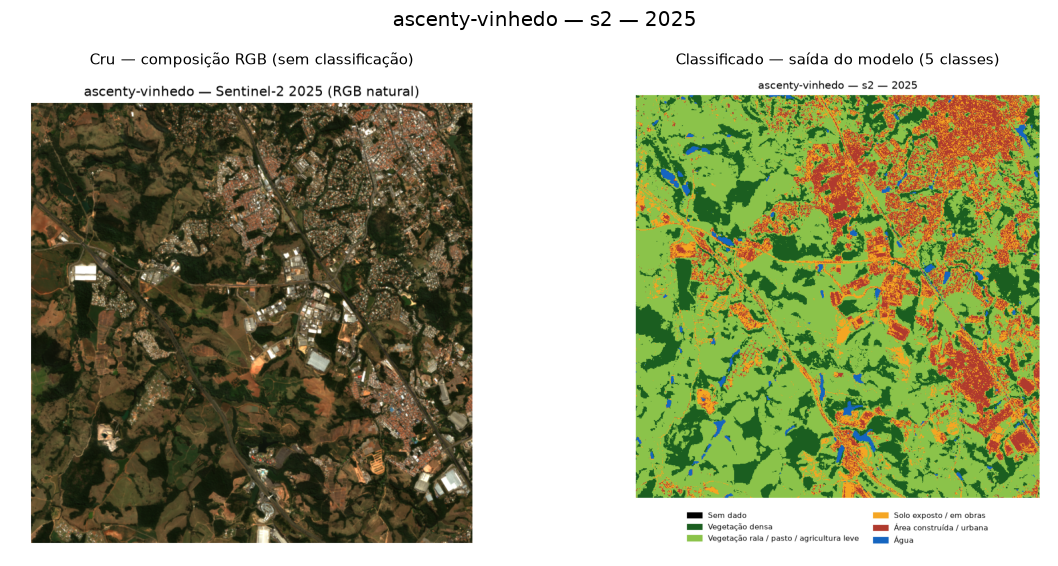

In [15]:
def mostrar_cru_vs_classificado(sensor_token: str, site_id: str, ano: int) -> None:
    cru_path = FIGURES_DIR / f"composto_{sensor_token}_{site_id}_{ano}.png"
    classificado_path = FIGURES_DIR / f"mapa_{sensor_token}_{site_id}_{ano}.png"

    fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
    axes[0].imshow(plt.imread(cru_path))
    axes[0].set_title("Cru — composição RGB (sem classificação)", fontsize=10)
    axes[0].axis("off")
    axes[1].imshow(plt.imread(classificado_path))
    axes[1].set_title("Classificado — saída do modelo (5 classes)", fontsize=10)
    axes[1].axis("off")
    fig.suptitle(f"{site_id} — {sensor_token} — {ano}", fontsize=13)
    fig.tight_layout()
    plt.show()


mostrar_cru_vs_classificado("s2", "ascenty-vinhedo", 2025)

**`ascenty-vinhedo` em 2025 (Sentinel-2, 10 m)**: à esquerda, a cena tal como o satélite capturou — só reflectância normalizada, nenhuma decisão do modelo. À direita, a mesma cena com cada pixel pintado pela classe que o modelo atribuiu (mesma legenda de cores usada em toda a seção 4). As manchas em tom terracota/marrom-avermelhado (classe 4, área construída/urbana) no painel classificado correspondem, no painel cru, a telhado e pavimento visíveis a olho nu — é essa correspondência visual, pixel a pixel, que dá confiança na decisão do modelo além do que as métricas numéricas das seções 2-3 já mostram.

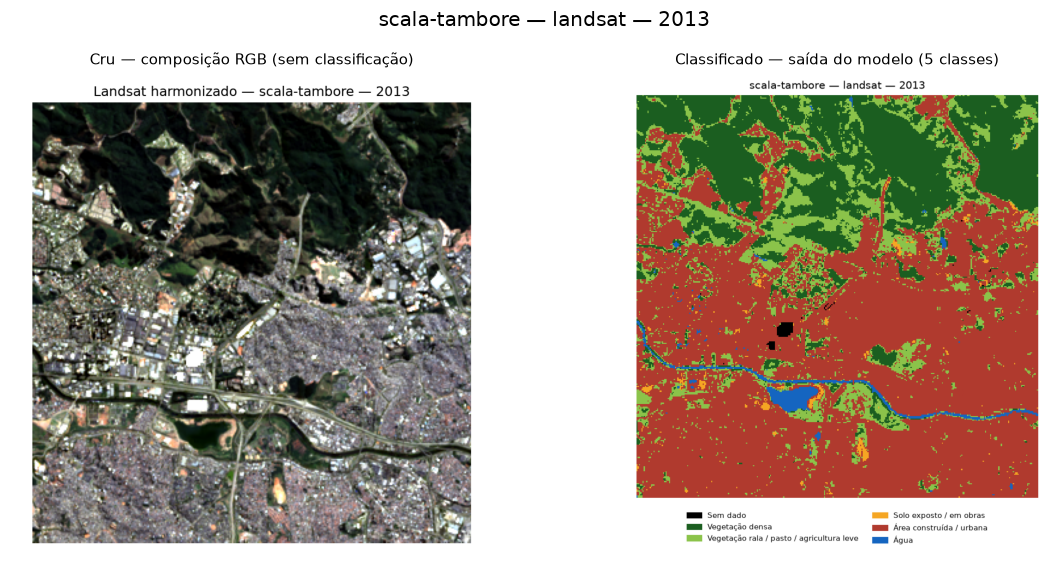

In [16]:
mostrar_cru_vs_classificado("landsat", "scala-tambore", 2013)

**`scala-tambore` em 2013 (Landsat, 30 m)**: mesmo exercício, mas no início da série e com o sensor de resolução mais grossa. Os pixels de 30 m tornam o painel cru visivelmente mais "blocado" que o par acima — e ajudam a entender, de forma visual, por que a classe 3 (solo exposto/obras) tem F1 mais baixo na era Landsat (seção 3): um canteiro de obras pequeno pode ficar abaixo da área mínima mapeável de um pixel Landsat, algo que não acontece com a mesma frequência nos 10 m do Sentinel-2.

### Uma obra específica, ano a ano

As seções acima comparam só ponta a ponta (2013 vs. 2025) ou pares isolados. Aqui, um único site — `ascenty-hortolandia` — ao longo de **5 anos** (2016, 2018, 2020, 2022, 2024), a janela de obra mais bem documentada dos 3 sites do projeto (`ano_inicio_obra=2018`, `periodo_pre="2015-2017"`, `periodo_durante="2018-2022"`, `periodo_pos="2023-2025"`, ver `config/sites.geojson`). Os dois primeiros anos vêm do raster Landsat, os três últimos do Sentinel-2 (mesmos rasters classificados já em disco, nenhuma inferência nova).

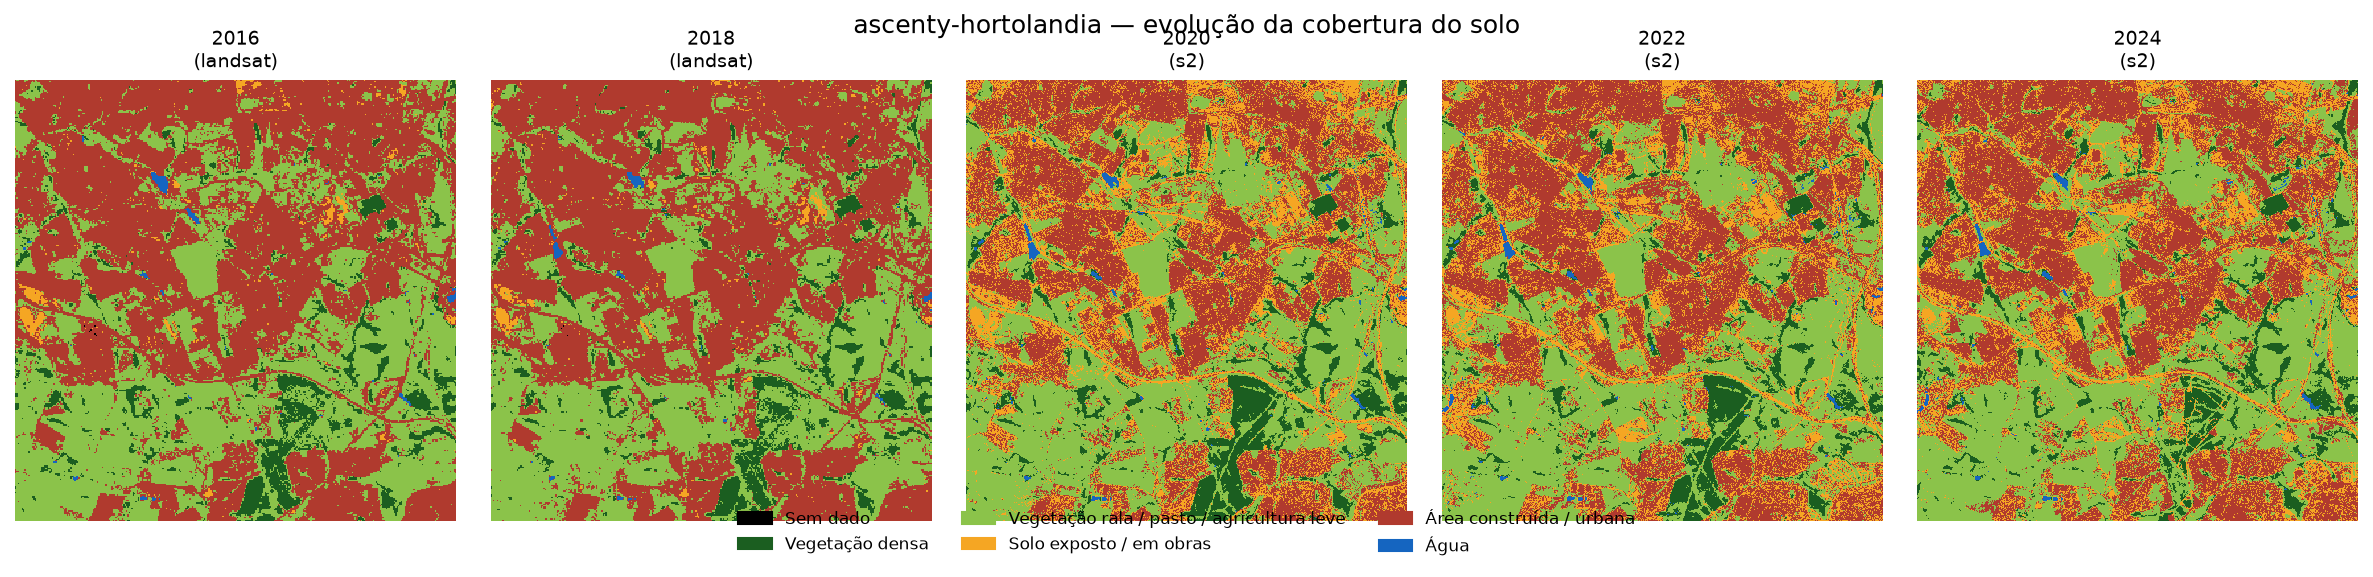

In [17]:
display(Image(filename=str(FIGURES_DIR / "evolucao_ascenty-hortolandia_painel.png")))

A obra começa em 2018 e se estende até 2022, com **6 prédios construídos ao longo do tempo** (não de uma vez só) — por isso vale ver ano a ano, não só antes/depois. Em 2016 e 2018 (Landsat) o entorno ainda é majoritariamente vegetação rala/pasto, com pouquíssimo solo exposto/obras visível na resolução de 30 m; a partir de 2020 (já Sentinel-2, 10 m) manchas de solo exposto/obras (laranja) aparecem espalhadas onde antes havia vegetação, e em 2022-2024 parte dessas manchas já virou área construída/urbana (vermelho) — o padrão gradual vegetação → solo exposto → construído se repetindo prédio a prédio, em vez de um salto único. **Ressalva:** a virada 2018→2020 também cruza a troca de sensor Landsat→Sentinel-2 (mesmo artefato de instrumento discutido na seção 5) — a resolução mais fina do Sentinel-2 por si só já revela mais solo exposto pequeno que o Landsat não capturava, então parte do salto visual nesse ponto é sensor, não só obra.

## 5. Evolução da classe crítica ao longo do tempo

Gráfico gerado neste notebook a partir de `outputs/indicadores/area_por_classe.csv` — área da classe 3 (solo exposto/obras) por ano, para os três sites acima. A linha é **separada por sensor** (traço contínuo = Landsat, tracejado = Sentinel-2) e a troca de instrumento em 2019 é marcada com uma linha vertical: **não é para ler o salto 2018→2019 como tendência real** — ver a célula de texto logo abaixo.

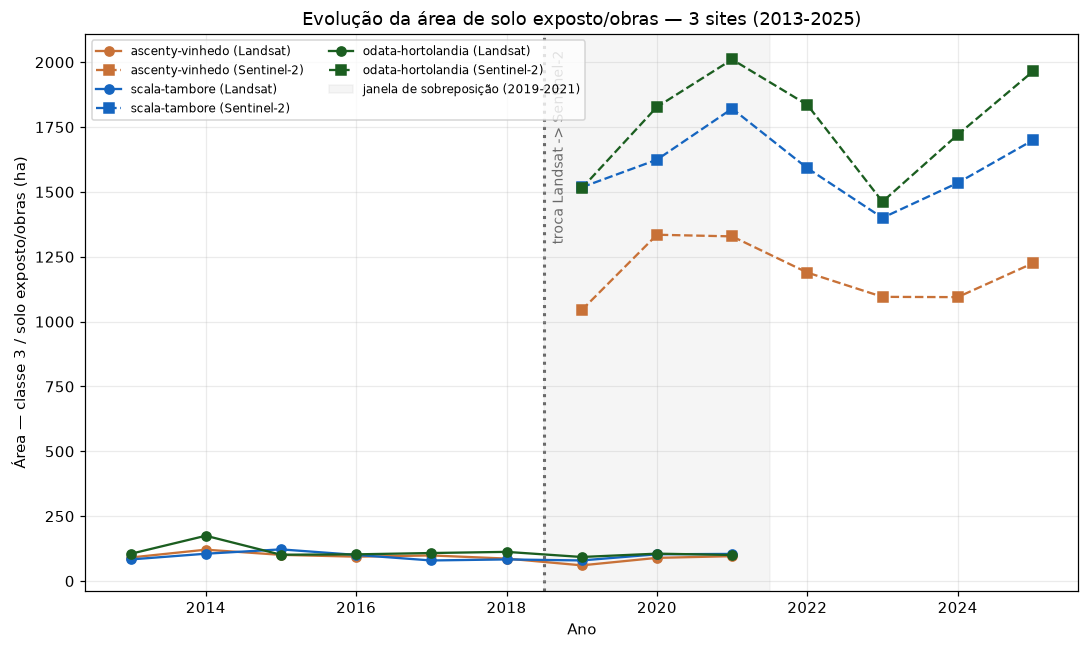

In [18]:
df_area = pd.read_csv(OUTPUTS_DIR / "area_por_classe.csv")

sites_interesse = ["ascenty-vinhedo", "scala-tambore", "odata-hortolandia"]
cores_site = {"ascenty-vinhedo": "#C87137", "scala-tambore": "#1565C0", "odata-hortolandia": "#1B5E20"}

classe3 = df_area[(df_area["classe_id"] == 3) & (df_area["site_id"].isin(sites_interesse))]

fig, ax = plt.subplots(figsize=(10, 6))
for site in sites_interesse:
    sub = classe3[classe3["site_id"] == site].sort_values("ano")
    landsat = sub[sub["sensor"] == "landsat"]
    s2 = sub[sub["sensor"] == "sentinel2"]
    ax.plot(landsat["ano"], landsat["area_ha"], marker="o", linestyle="-", color=cores_site[site], label=f"{site} (Landsat)")
    ax.plot(s2["ano"], s2["area_ha"], marker="s", linestyle="--", color=cores_site[site], label=f"{site} (Sentinel-2)")

ax.axvline(2018.5, color="dimgray", linestyle=":", linewidth=2, zorder=0)
ax.axvspan(2018.5, 2021.5, color="gray", alpha=0.08, zorder=0, label="janela de sobreposição (2019-2021)")
ymin, ymax = ax.get_ylim()
ax.text(2018.6, ymax * 0.97, "troca Landsat -> Sentinel-2", rotation=90, va="top", ha="left", fontsize=9, color="dimgray")

ax.set_xlabel("Ano")
ax.set_ylabel("Área — classe 3 / solo exposto/obras (ha)")
ax.set_title("Evolução da área de solo exposto/obras — 3 sites (2013-2025)")
ax.legend(fontsize=8, ncol=2, loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

**Por que a linha é quebrada em 2019 (e não corrigida/emendada):** `reports/validacao_sensores.md` (SV-20, reconfirmado com `rf_v1.0-tuned`) mediu, nos 48 pares site×ano de sobreposição disponíveis, que o salto de área de classe 3 entre 2018 e 2019 (~1.253 ha em média, na série bruta) é **quase idêntico** ao artefato isolado de troca de sensor (~1.263 ha, medido controlando a resolução) — enquanto a mudança real no mesmo sensor (Landsat 2018 vs. Landsat no mesmo ano de sobreposição) é de apenas −9,5 ha em média. Em **48 de 48 sites (100%)** o degrau publicado é classificado como indistinguível do artefato de instrumento. Por isso a classe 3 é publicada em **duas faixas separadas, sem correção nem emenda**, entre a era Landsat e a era Sentinel-2 (tratamento (c) da seção 6 de `validacao_sensores.md`) — ao contrário da classe 4 (construída/urbana), que recebeu um fator de correção por site porque o viés ali se mostrou estável e homogêneo o bastante entre sites. **Qualquer leitura de crescimento real de solo exposto que atravesse 2018→2019 sem considerar isso está enxergando o satélite, não o território.**

### Exemplo concreto: a mesma obra, duas leituras muito diferentes

Pra deixar o achado acima menos abstrato: `ascenty-vinhedo` começou a obra exatamente em 2019 — o pior caso possível, bem em cima da troca de satélite. Comparamos duas formas de ler a mesma série real:

- **Misturando satélites** (o que a série oficial recomendada faz: Landsat até 2018, Sentinel-2 de 2019 em diante) — mostra um salto de ~86 ha (2018) para ~1.044 ha (2019), quase 12x em 1 ano.
- **Só Landsat** (mesmo sensor do início ao fim, disponível até 2021 para este site por causa da janela de sobreposição ingerida de propósito) — mostra a área praticamente **parada** no mesmo período real (86 → 60 → 89 → 96 ha).

A diferença entre as duas linhas não é a obra — é o instrumento. É exatamente por isso que a classe crítica é publicada em faixas separadas, nunca emendada.

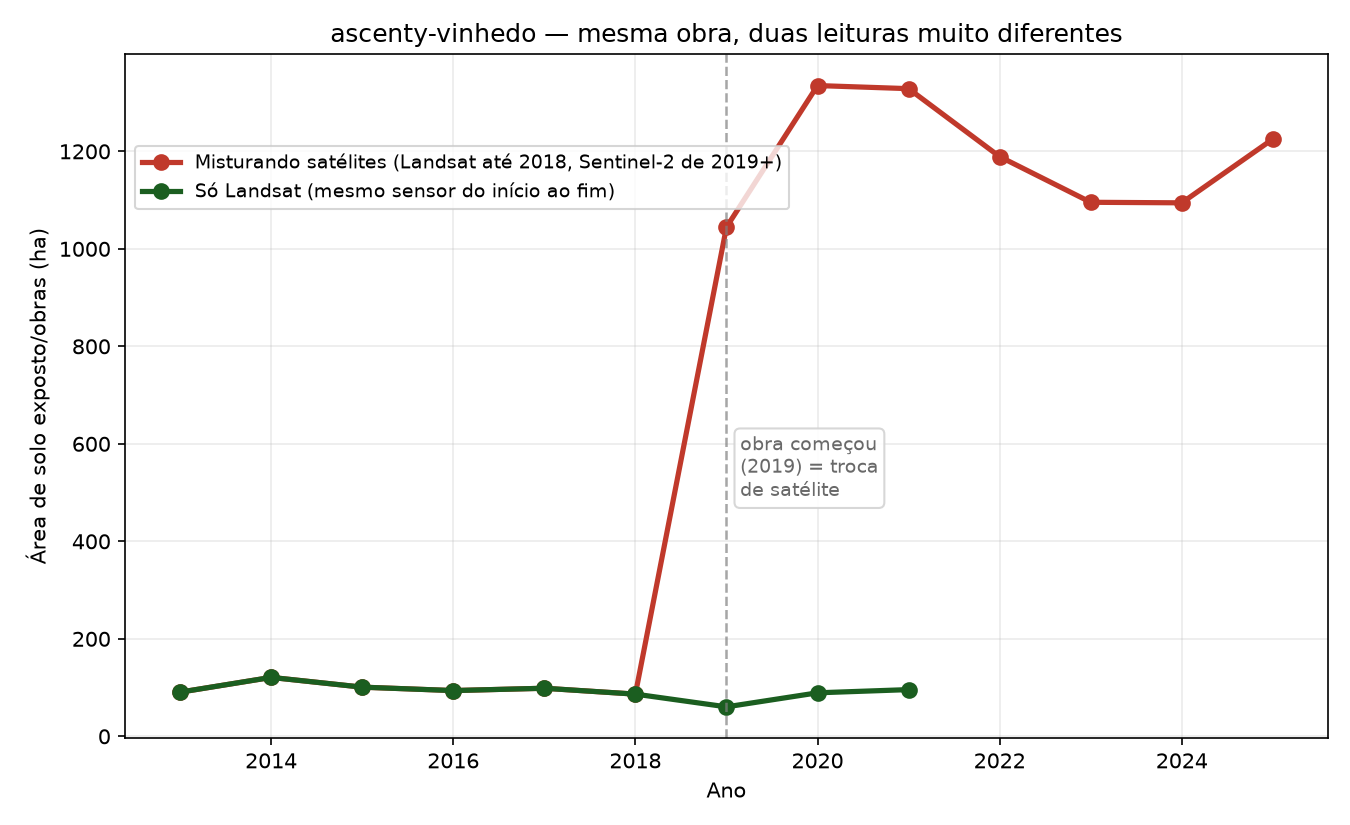

In [19]:
from IPython.display import Image, display

caminho = REPO_ROOT / 'reports' / 'figures' / 'exemplo_misturar_vs_so_landsat_ascenty-vinhedo.png'
display(Image(filename=str(caminho)))

## 6. Limitações honestas

- **F1 da classe 3 varia muito por site** (0.216 a 0.818 no holdout espacial) — o modelo generaliza espectralmente até um ponto, mas não compensa totalmente a escassez de exemplos por região; sites com poucos exemplos de treino de solo exposto/obras ficam bem abaixo da média.
- **O degrau de sensor em 2019 precisa ser lido com cuidado**: como mostrado na seção 5, boa parte (ou a totalidade, no caso da classe 3) da diferença aparente entre Landsat e Sentinel-2 é artefato de instrumento/resolução, não mudança real de terreno — série publicada em faixas separadas para essa classe, exatamente por isso.
- **Ausência de grupo de controle para afirmação de causalidade**: este notebook mostra correlação entre a série de classes e o tempo, não faz nem sustenta nenhuma afirmação de que a presença do data center *causou* as mudanças observadas. Um grupo de controle pareado (área comparável sem data center) está sendo construído em paralelo pelo time (frente de Indicadores/causalidade) e não está incorporado aqui.
- **Fonte de label**: MapBiomas Coleção 9 não tem uma classe "canteiro de obras" — o remap usa proxies ("Área não Vegetada", "Mineração", "Afloramento Rochoso"), fonte de ruído estrutural na classe 3 que nenhum ajuste de modelo resolve sozinho (ADR-004).

## 7. Conclusão

O modelo `rf_v1.0-tuned` bate a meta informal de macro-F1 ≥ 0.70 em todos os recortes de holdout testados, e a meta de F1(classe 3) ≥ 0.55 no holdout espacial principal — mas fica abaixo dela no teste mais difícil (AOI nunca vista) e tem desempenho desigual entre sites, o que é esperado num V1 supervisionado com poucos exemplos rotulados manualmente para a classe crítica. Os mapas classificados e o gráfico de série temporal mostram que o pipeline já conta a história central do projeto — vegetação/pasto → solo exposto → construído — de ponta a ponta, com o cuidado explícito de não confundir artefato de sensor com sinal real. Os próximos passos (grupo de controle, rotulagem manual complementar, entrega formal de notebooks/model card em SV-17) endereçam as limitações listadas acima.